--- Simulation Results ---
Max Decay Rate: 9.03e-21 s^-1
Min Decay Rate: 8.97e-21 s^-1
Average Decay Rate: 9.00e-21 s^-1
Peak Time: 15.06 s

--- Anomalies (Time, Gamma) ---
t = 7.21 s, Γ = 8.99e-21 s^-1
t = 13.62 s, Γ = 8.99e-21 s^-1
t = 20.04 s, Γ = 9.00e-21 s^-1
t = 26.38 s, Γ = 9.00e-21 s^-1
t = 32.79 s, Γ = 8.99e-21 s^-1
t = 39.21 s, Γ = 8.98e-21 s^-1
t = 45.62 s, Γ = 9.00e-21 s^-1
t = 52.04 s, Γ = 8.99e-21 s^-1
t = 58.38 s, Γ = 9.00e-21 s^-1
t = 64.79 s, Γ = 8.99e-21 s^-1


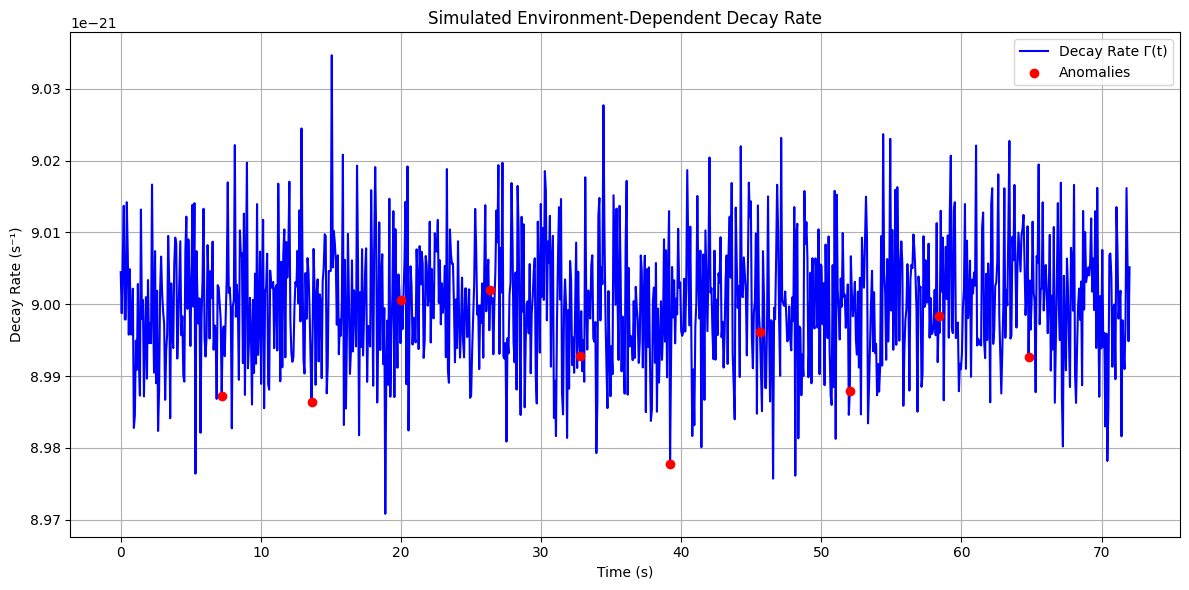

In [ ]:
import numpy as np

import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp



# --- Constants ---

lambda_0 = 9.0e-21  # Base decay rate (s^-1)

T_bound = 2.3e17    # Normalization factor (e.g., GeV^4)

c = 3e8             # Speed of light (m/s)



# --- Parameters ---

beta_0 = 1.0e-21    # Coupling to scalar field

beta_1 = 0.0        # Spatial coupling (unused)

m_phi_squared = 1e-8 # Scalar mass squared (m^-2) - Increased for stronger restoring force

kappa = 1e-16       # Scalar coupling (tuned down to avoid initial overflow)

eta = 1e6           # Backreaction coupling (smaller to ensure stability)

sigma_epsilon = 1e-6 # Noise variance

alpha = 1e-3        # Damping coefficient (new)



# --- Grids ---

t_duration = 72

x_max = c * t_duration

x = np.linspace(0, x_max, 1000)

time_grid = x / c



# --- Anomalies: 10 Gaussian peaks ---

T_0 = 1e15

sigma_x = x_max / 100

anomaly_positions = np.linspace(0.1, 0.9, 10) * x_max



def T_smooth(current_x):

    T = 0

    for pos in anomaly_positions:

        T += T_0 * np.exp(- (current_x - pos)**2 / (2 * sigma_x**2))

    return min(T, 1e18)  # Prevent T from becoming excessively large



def dphi_dx(current_x, state):

    """

    Stable 1D scalar field equation of motion with restoring force and damping:

    d^2phi/dx^2 = -m_phi_squared * phi - kappa * T/T_bound - alpha * dphi/dx

    """

    phi, phi_prime = state

    T = T_smooth(current_x)



    restoring_force = -m_phi_squared * phi

    source = -kappa * T / T_bound

    damping = -alpha * phi_prime



    d2phi_dx2 = restoring_force + source + damping

    return [phi_prime, d2phi_dx2]



# --- Initial conditions ---

phi_0 = [0.51, 0.0]



# --- Solve scalar field equation ---

sol = solve_ivp(dphi_dx, [x[0], x[-1]], phi_0, method='BDF', rtol=1e-3, atol=1e-6)



if not sol.success:

    raise RuntimeError("ODE solver failed:", sol.message)



# --- Interpolate results ---

phi_result = np.interp(x, sol.t, sol.y[0])

partial_phi_dx = np.gradient(phi_result, x)

delta_obs = eta * partial_phi_dx**2



# --- Noise ---

np.random.seed(42)

epsilon = np.random.normal(0, np.sqrt(sigma_epsilon), len(x))



# --- Gamma computation ---

decay_factor = 1 + beta_0 * np.exp(-phi_result) + beta_1 * x + delta_obs + epsilon

decay_factor = np.maximum(0, decay_factor) # Ensure decay factor is non-negative

Gamma_final = lambda_0 * decay_factor



# --- Check for NaNs or infs ---

if not np.all(np.isfinite(Gamma_final)):

    raise ValueError("Gamma contains non-finite values (NaN or inf)")



# --- Output ---

print("--- Simulation Results ---")

print(f"Max Decay Rate: {np.max(Gamma_final):.2e} s^-1")

print(f"Min Decay Rate: {np.min(Gamma_final):.2e} s^-1")

print(f"Average Decay Rate: {np.mean(Gamma_final):.2e} s^-1")

print(f"Peak Time: {time_grid[np.argmax(Gamma_final)]:.2f} s")



# --- Anomaly reporting ---

anomaly_indices = [np.argmin(np.abs(x - pos)) for pos in anomaly_positions]

print("\n--- Anomalies (Time, Gamma) ---")

for idx in anomaly_indices:

    print(f"t = {time_grid[idx]:.2f} s, Γ = {Gamma_final[idx]:.2e} s^-1")



# --- Plotting ---

plt.figure(figsize=(12, 6))

plt.plot(time_grid, Gamma_final, label="Decay Rate Γ(t)", color='blue')

plt.scatter(time_grid[anomaly_indices], Gamma_final[anomaly_indices],

            color='red', label="Anomalies", zorder=5)

plt.xlabel("Time (s)")

plt.ylabel("Decay Rate (s⁻¹)")

plt.title("Simulated Environment-Dependent Decay Rate")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

